In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scipy.ndimage as ndimage
import glob, os, shutil, cv2, json, sys
from tqdm import tqdm
from pathlib import Path

In [2]:
BASE_PATH = '../Dataset/dataset_synthetic'

In [3]:
def getFiles(path, limit=None, shuffle=False):
    target = sorted([os.path.abspath(f) for f in glob.glob(os.path.join(path, '*'))])
    if shuffle:
        np.random.shuffle(target)     
    return target[:limit]

def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)


OPTIONS = json.loads(open('../../Task/info.json', 'r').read())
OPTIONS['dataset'] = BASE_PATH.split('/')[-1].strip()
OPTIONS

{'network': 'unet3d_v2',
 'dataset': 'dataset_synthetic',
 'img_size': None,
 'lr': 0.001,
 'loss': 'dice_focal',
 'batch_size': 4,
 'scheduler': 'plateau',
 'dropout': 0.1,
 'num_filters': 16}

In [4]:
with open('../../Task/info.json', 'w', encoding='utf-8') as file:
    json.dump(OPTIONS, file, ensure_ascii=False, indent=4) 

# CONVERTENDO IMAGENS

In [5]:
images = getFiles('original/images')
masks  = getFiles('original/masks')

print(images[0])
print(masks[0])

/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Searcher/Dataset/dataset_synthetic/original/images/img_0000.npy
/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Searcher/Dataset/dataset_synthetic/original/masks/img_0000.npy




 showing index 0: img_0000.npy


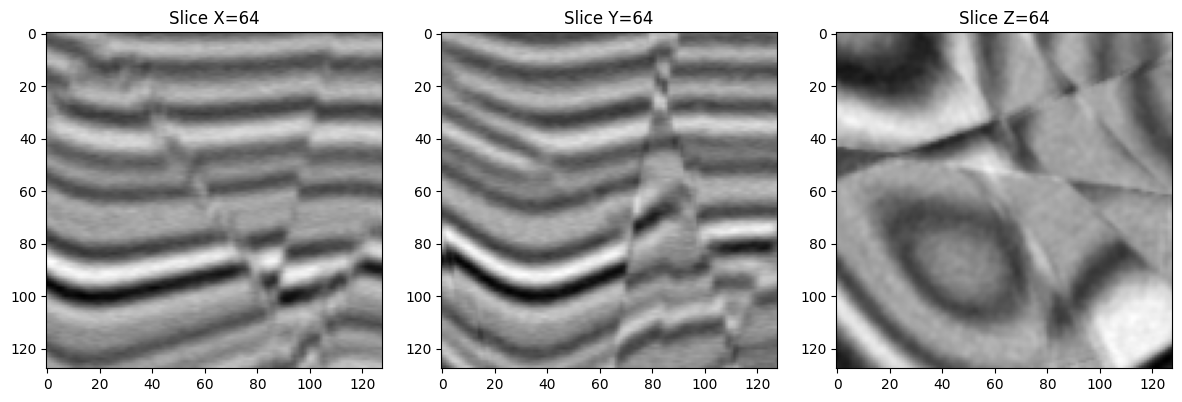

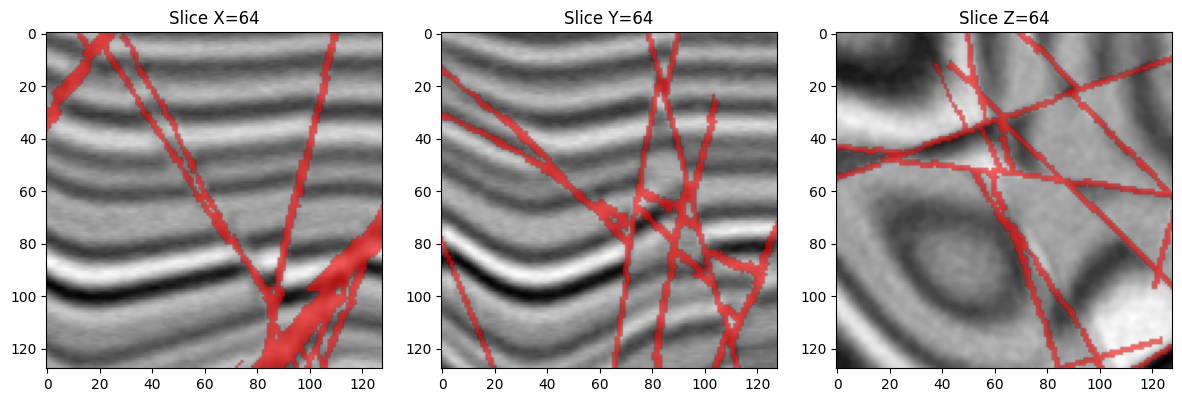

In [6]:
def getImage(base_path, file_name=None):
    path = os.path.join(base_path, file_name) if file_name else base_path
    return np.load(path)

def showTile(img=None, mask=None, save=None):
    if img is None and mask is None:
        return print("Erro: Forneça pelo menos 'img' ou 'mask'.")

    ref_vol = img if img is not None else mask
    mid_x = ref_vol.shape[0] // 2
    mid_y = ref_vol.shape[1] // 2
    mid_z = ref_vol.shape[2] // 2

    def get_slices(vol):
        if vol is None:
            return None
        
        s_x = np.array(vol[mid_x, :, :]) # Plano YZ
        s_y = np.array(vol[:, mid_y, :]) # Plano XZ
        s_z = np.array(vol[:, :, mid_z]) # Plano XY
        return [s_x, np.rot90(s_z, -1), s_y]

    img_slices  = get_slices(img)
    mask_slices = get_slices(mask)
    cmap_mask_only    = ListedColormap(['black', 'red', 'green', 'blue'])
    cmap_mask_overlay = ListedColormap([(0, 0, 0, 0), 'red', 'green', 'blue'])

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    titles    = [f'Slice X={mid_x}', f'Slice Y={mid_y}', f'Slice Z={mid_z}']

    for i, ax in enumerate(axes):
        if img is not None:
            ax.imshow(img_slices[i], cmap='gray')
            
        if mask is not None:
            if img is not None:
                ax.imshow(mask_slices[i], cmap=cmap_mask_overlay, vmin=0, vmax=3, alpha=0.6)
            else:
                ax.imshow(mask_slices[i], cmap=cmap_mask_only, vmin=0, vmax=3)
        
        ax.set_title(titles[i])

    plt.tight_layout()

    if save:
        plt.savefig(save, bbox_inches='tight', dpi=300)
        return plt.close(fig)

    plt.show()

for i, (img_path, msk_path) in enumerate(zip(images, masks)):
    if i == 1:
        break

    file_name = Path(img_path).name
    print(f'\n\n showing index {i}:', file_name)

    img  = getImage('original/images', file_name)
    mask = getImage('original/masks',  file_name)

    showTile(img=img)
    showTile(img=img, mask=mask)

### Opcional - Normalização com Percentil

In [7]:
arrays = [np.load(path) for path in images]
p01 = np.percentile(arrays, 1)
p99 = np.percentile(arrays, 99)
print(p01, p99); del arrays

def normalize(img):
    clipped = np.clip(img, p01, p99)   
    return (clipped - p01) / (p99 - p01)

-2.3377888 2.361104


In [8]:
setFolder('images')
setFolder('masks')

for img_path, msk_path in tqdm(zip(images, masks), total=len(images)):
    img = getImage('original/images', img_path)
    msk = getImage('original/masks',  msk_path)

    img = normalize(img)
    file_name = Path(img_path).name
    
    np.save(os.path.join('images', file_name), img)
    np.save(os.path.join('masks',  file_name),  msk)

  0%|                                                                                                    | 0/220 [00:00<?, ?it/s]

  1%|▊                                                                                           | 2/220 [00:00<00:44,  4.90it/s]

  1%|█▎                                                                                          | 3/220 [00:00<00:51,  4.21it/s]

  2%|█▋                                                                                          | 4/220 [00:34<45:25, 12.62s/it]

  2%|██                                                                                          | 5/220 [00:34<30:13,  8.43s/it]

...

 97%|███████████████████████████████████████████████████████████████████████████████████████▏  | 213/220 [11:02<00:00, 13.03it/s]

 98%|███████████████████████████████████████████████████████████████████████████████████████▉  | 215/220 [11:02<00:00, 12.24it/s]

 99%|████████████████████████████████████████████████████████████████████████████████████████▊ | 217/220 [11:03<00:00, 11.64it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████▌| 219/220 [11:03<00:00, 12.32it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████| 220/220 [11:03<00:00,  3.02s/it]

In [9]:
df = [] 

for img_path, mask_path in tqdm(zip(getFiles('images'), getFiles('masks'))):
    img  = np.load(img_path)
    mask = np.load(mask_path)
    data = dict()

    data['id'] = Path(img_path).name
    data['img_min']  = np.min(img)
    data['img_max']  = np.max(img)
    data['img_mean'] = np.mean(img)
    data['img_std']  = np.std(img)

    data['msk_min'] = np.min(mask)
    data['msk_max'] = np.max(mask)

    data['shape'] = img.shape
    data['img_path']  = img_path
    data['mask_path'] = mask_path
    df.append(data)


df = pd.DataFrame(df)
print(df.img_path.iloc[2])
df

0it [00:00, ?it/s]

11it [00:00, 104.83it/s]

25it [00:00, 121.97it/s]

41it [00:00, 135.36it/s]

55it [00:00, 130.35it/s]

...

200it [00:01, 157.59it/s]

218it [00:01, 162.05it/s]

220it [00:01, 146.43it/s]

/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Searcher/Dataset/dataset_synthetic/images/img_0002.npy


,id,img_min,img_max,img_mean,img_std,msk_min,msk_max,shape,img_path,mask_path
0,img_0000.npy,0.0,1.0,0.498232,0.209052,0,1,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
1,img_0001.npy,0.0,1.0,0.496812,0.210843,0,1,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
2,img_0002.npy,0.0,1.0,0.497450,0.212524,0,1,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
3,img_0003.npy,0.0,1.0,0.497590,0.212298,0,1,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
4,img_0004.npy,0.0,1.0,0.498554,0.205370,0,1,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
...,...,...,...,...,...,...,...,...,...,...
215,img_0215.npy,0.0,1.0,0.497490,0.212493,0,1,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
216,img_0216.npy,0.0,1.0,0.496803,0.209298,0,1,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
217,img_0217.npy,0.0,1.0,0.497174,0.209274,0,1,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
218,img_0218.npy,0.0,1.0,0.497037,0.211539,0,1,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...


In [10]:
df.to_csv('../DataBase.csv', index=None)